# Regression Model

--- Model Comparison Table ---
                   Model     MSE      R2
0      Linear Regression  0.0000  1.0000
1       Ridge Regression  0.0000  1.0000
4  Polynomial Regression  0.0000  1.0000
3            Elastic Net  1.2380  0.7575
2       Lasso Regression  2.0744  0.5937

Best-Fit Model: Linear Regression

Regression Equation for Linear Regression:
y = 0.0 + (0.0 * age) + (1.0 * social_media_hours) + (1.0 * work_or_study_hours) + (1.0 * entertainment_hours)


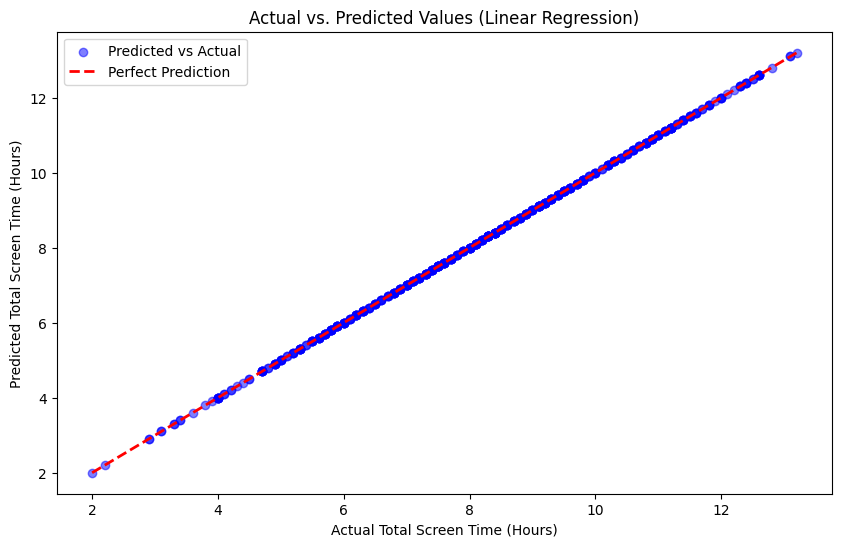

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

# 1. Loading and Preprocessing the Data
df = pd.read_csv("daily_internet_usage_by_age_group.csv")

cols_to_use = ['age', 'social_media_hours', 'work_or_study_hours', 'entertainment_hours']
target = 'total_screen_time'

df[cols_to_use] = df[cols_to_use].fillna(df[cols_to_use].mean())
df[target] = df[target].fillna(df[target].mean())

# 2. Detecting and Removing Outliers (IQR Method)
def remove_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower) & (df[col] <= upper)]
    return df

df_cleaned = remove_outliers(df, cols_to_use + [target])

# 3. Splitting the Data
X = df_cleaned[cols_to_use]
y = df_cleaned[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Applying Regression Models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "Elastic Net": ElasticNet()
}

results = []

# Train standard models
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results.append({
        "Model": name,
        "MSE": round(mean_squared_error(y_test, y_pred), 4),
        "R2": round(r2_score(y_test, y_pred), 4)
    })

# Polynomial Regression
poly = PolynomialFeatures(degree=2)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_poly_train, y_train)
y_poly_pred = poly_model.predict(X_poly_test)

results.append({
    "Model": "Polynomial Regression",
    "MSE": round(mean_squared_error(y_test, y_poly_pred), 4),
    "R2": round(r2_score(y_test, y_poly_pred), 4)
})

# 5 & 6. Model Comparison & Best Model
results_df = pd.DataFrame(results).sort_values(by="R2", ascending=False)

print("--- Model Comparison Table ---")
print(results_df)

best_model_name = results_df.iloc[0]["Model"]
print(f"\nBest-Fit Model: {best_model_name}")

# 7. Printing the Regression Equation
print(f"\nRegression Equation for {best_model_name}:")

if best_model_name == "Polynomial Regression":
    best_model = poly_model
    coefs = best_model.coef_
    intercept = round(best_model.intercept_, 2)

    print(f"Intercept: {intercept}")
    print("Polynomial coefficients:")
    for i, coef in enumerate(coefs):
        print(f"Feature {i}: {round(coef, 4)}")

else:
    best_model = models[best_model_name]
    intercept = round(best_model.intercept_, 2)
    coefs = [round(c, 2) for c in best_model.coef_]

    print(f"y = {intercept} + ({coefs[0]} * age) + ({coefs[1]} * social_media_hours) + ({coefs[2]} * work_or_study_hours) + ({coefs[3]} * entertainment_hours)")

    # 8. Visualization
plt.figure(figsize=(10, 6))

if best_model_name == "Polynomial Regression":
    y_best = y_poly_pred
else:
    y_best = best_model.predict(X_test)

plt.scatter(y_test, y_best, color='blue', alpha=0.5, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect Prediction')

plt.xlabel("Actual Total Screen Time (Hours)")
plt.ylabel("Predicted Total Screen Time (Hours)")
plt.title(f"Actual vs. Predicted Values ({best_model_name})")
plt.legend()
plt.show()

# Classification Model


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score, classification_report)

# Load dataset
df = pd.read_csv("daily_internet_usage_by_age_group.csv")

# Create categorical target variable
df['usage_category'] = df['total_screen_time'].apply(
    lambda x: 'High Usage' if x > 8.5 else 'Low Usage'
)

# Check class distribution
print("Class Distribution in Original Dataset:")
print(df['usage_category'].value_counts())
print()

# Encode categorical variables
# Create dummy variables for nominal categories
df_encoded = pd.get_dummies(df, columns=['primary_device', 'internet_type'], drop_first=True)

# Label encode ordinal variable (age_group)
le = LabelEncoder()
df_encoded['age_group_encoded'] = le.fit_transform(df['age_group'])

# Select features
feature_cols = ['age', 'social_media_hours', 'work_or_study_hours',
                'entertainment_hours', 'age_group_encoded']

# Add device and internet type dummies
device_cols = [col for col in df_encoded.columns if col.startswith('primary_device_')]
internet_cols = [col for col in df_encoded.columns if col.startswith('internet_type_')]
feature_cols.extend(device_cols)
feature_cols.extend(internet_cols)

X = df_encoded[feature_cols]
y = df_encoded['usage_category']

# Split the data (80% training, 20% testing) with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define classification models
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100)
}

# Store results
results = []

print("=" * 80)
print("CLASSIFICATION MODEL RESULTS")
print("=" * 80)

for name, model in models.items():
    # Train the model
    model.fit(X_train_scaled, y_train)

    # Make predictions
    y_pred = model.predict(X_test_scaled)

    # Calculate metrics
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label='High Usage')
    recall = recall_score(y_test, y_pred, pos_label='High Usage')
    f1 = f1_score(y_test, y_pred, pos_label='High Usage')

    # Store results
    results.append({
        "Model": name,
        "Confusion Matrix": cm,
        "TP": tp, "TN": tn, "FP": fp, "FN": fn,
        "Errors (FP+FN)": fp + fn,
        "Accuracy": accuracy
    })

    # Print detailed results for each model
    print(f"\n{'-' * 60}")
    print(f"Model: {name}")
    print(f"{'-' * 60}")
    print(f"Confusion Matrix:")
    print(f"              Predicted")
    print(f"              Low    High")
    print(f"Actual Low    {tn:4d}    {fp:4d}")
    print(f"       High   {fn:4d}    {tp:4d}")
    print(f"\nErrors (False Positives + False Negatives): {fp + fn}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")

# Create comparison table
print("\n" + "=" * 80)
print("CROSS-VALIDATION CLASSIFICATION MODEL RESULTS")
print("=" * 80)

results_df = pd.DataFrame(results)[["Model", "Confusion Matrix", "Errors (FP+FN)", "Accuracy"]]
print(results_df.to_string(index=False))

# Find best model
best_model_name = results_df.loc[results_df["Accuracy"].idxmax(), "Model"]
best_accuracy = results_df["Accuracy"].max()
print(f"\n{'=' * 80}")
print(f"BEST-FIT CLASSIFIER: {best_model_name} (Accuracy: {best_accuracy:.4f})")
print(f"{'=' * 80}")

# Train best model on full training data and make final predictions
best_model = models[best_model_name]
best_model.fit(X_train_scaled, y_train)
final_predictions = best_model.predict(X_test_scaled)

# Class Distribution Analysis
print("\n" + "=" * 80)
print("CLASS DISTRIBUTION ANALYSIS")
print("=" * 80)

print("\nActual Class Distribution in Test Set:")
print(y_test.value_counts())

print("\nPredicted Class Distribution by Best-Fit Classifier:")
predicted_series = pd.Series(final_predictions)
print(predicted_series.value_counts())

print("\nDetailed Classification Report for Best-Fit Model:")
print(classification_report(y_test, final_predictions, target_names=['Low Usage', 'High Usage']))

# Number of elements in each category based on best-fit classifier
print("=" * 80)
print("NUMBER OF ELEMENTS IN EACH CATEGORY")
print("=" * 80)

# Using the best-fit classifier (Logistic Regression)
best_model = LogisticRegression(random_state=42, max_iter=1000)
best_model.fit(X_train_scaled, y_train)
predictions = best_model.predict(X_test_scaled)

category_counts = pd.Series(predictions).value_counts()
print("\nBased on Best-Fit Classifier (Logistic Regression):")
print(category_counts)

# Also show percentages
print("\nWith Percentages:")
print(pd.Series(predictions).value_counts(normalize=True) * 100)

Class Distribution in Original Dataset:
usage_category
Low Usage     1578
High Usage    1222
Name: count, dtype: int64

CLASSIFICATION MODEL RESULTS

------------------------------------------------------------
Model: Logistic Regression
------------------------------------------------------------
Confusion Matrix:
              Predicted
              Low    High
Actual Low     244       0
       High      1     315

Errors (False Positives + False Negatives): 1
Accuracy: 0.9982
Precision: 0.9959
Recall: 1.0000
F1-Score: 0.9980

------------------------------------------------------------
Model: K-Nearest Neighbors
------------------------------------------------------------
Confusion Matrix:
              Predicted
              Low    High
Actual Low     224      20
       High     19     297

Errors (False Positives + False Negatives): 39
Accuracy: 0.9304
Precision: 0.9218
Recall: 0.9180
F1-Score: 0.9199

------------------------------------------------------------
Model: Naive Bay

# Cluster Analysis

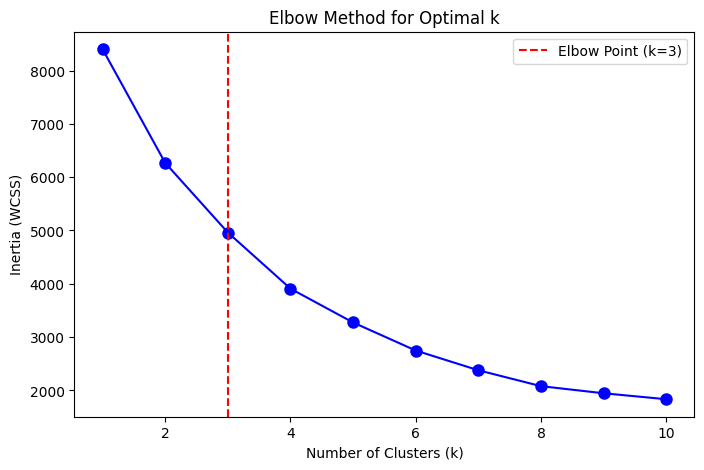

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("daily_internet_usage_by_age_group.csv")

# Select features for clustering
X_cluster = df[['social_media_hours', 'work_or_study_hours', 'entertainment_hours']]

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Elbow Method to find optimal k
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, 'bo-', markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method for Optimal k')
plt.axvline(x=3, color='r', linestyle='--', label='Elbow Point (k=3)')
plt.legend()
plt.show()

METHOD 1: K-MEANS CLUSTERING

K-Means Cluster Centers (in original units):
   social_media_hours  work_or_study_hours  entertainment_hours
0            2.153247             2.404486             2.616057
1            2.187854             3.980731             1.120365
2            1.991259             5.652214             2.586014

K-Means Cluster Distribution:
KMeans_Cluster
0     848
1    1094
2     858
Name: count, dtype: int64

METHOD 2: HIERARCHICAL CLUSTERING


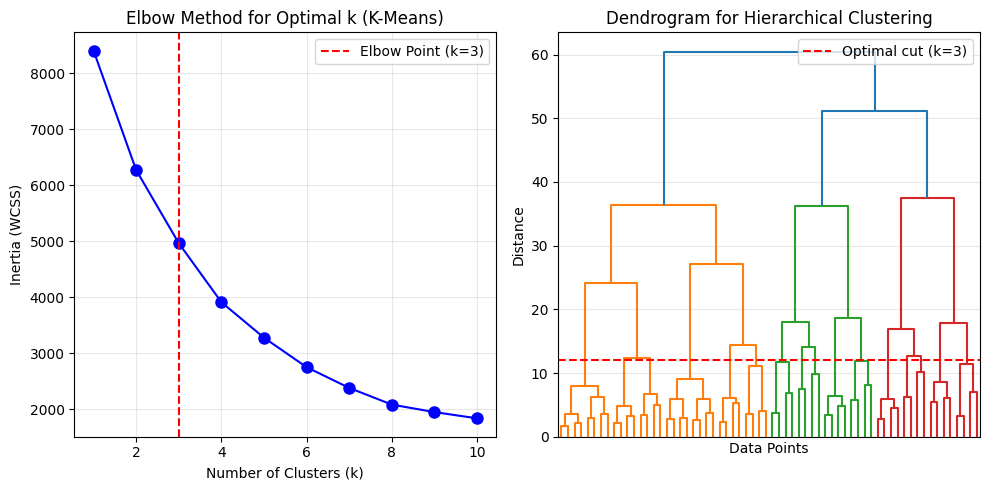


Hierarchical Cluster Distribution:
Hierarchical_Cluster
1    949
2    965
3    886
Name: count, dtype: int64

Hierarchical Cluster Centers:
                      social_media_hours  work_or_study_hours  \
Hierarchical_Cluster                                            
1                               3.371549             4.116544   
2                               1.580829             3.781451   
3                               1.357675             4.164108   

                      entertainment_hours  
Hierarchical_Cluster                       
1                                2.055321  
2                                1.310466  
3                                2.761061  


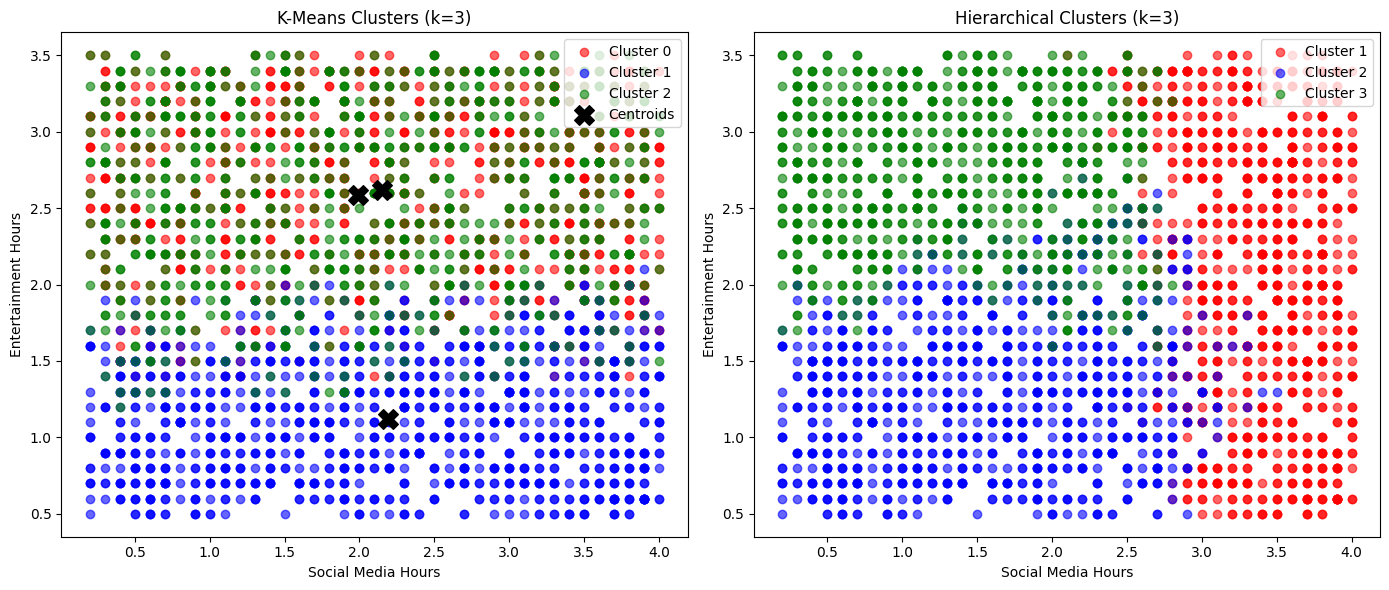

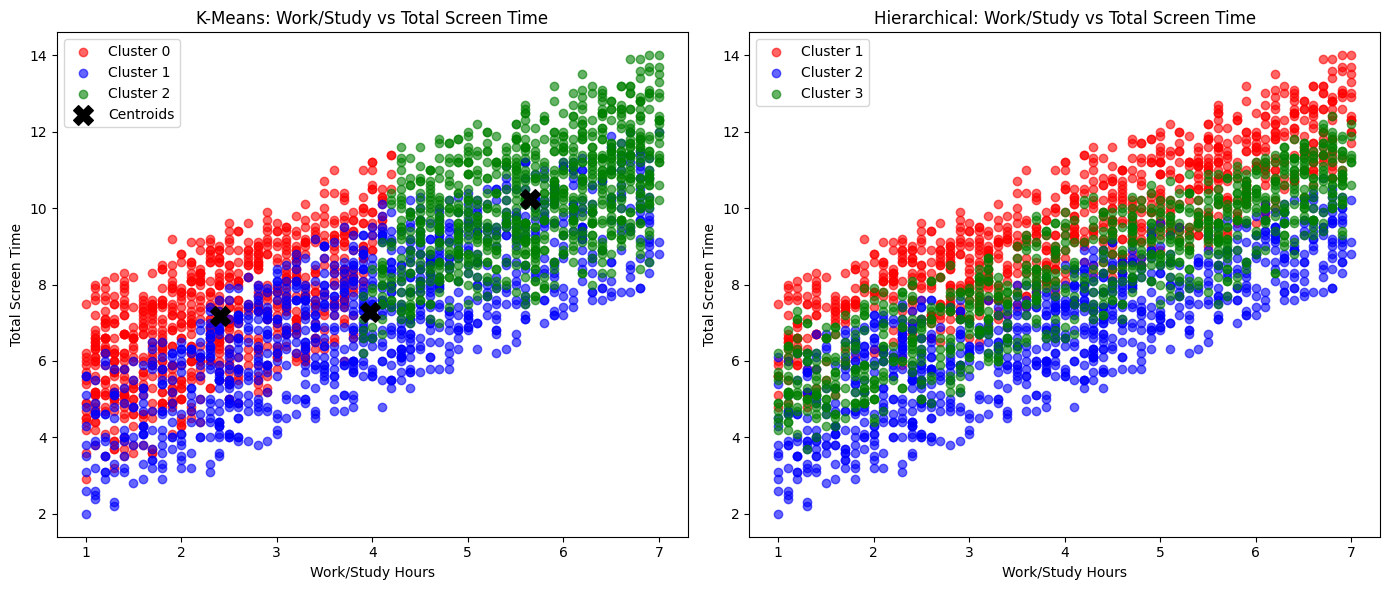


COMPARISON OF CLUSTERING METHODS

Cluster Size Comparison:
   K-Means  Hierarchical
0    848.0           NaN
1   1094.0         949.0
2    858.0         965.0
3      NaN         886.0

Agreement between methods: 1498/2800 samples (53.50%)


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Load dataset
df = pd.read_csv("daily_internet_usage_by_age_group.csv")

# Select features for clustering
X_cluster = df[['social_media_hours', 'work_or_study_hours', 'entertainment_hours']]

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# ============================================
# METHOD 1: K-MEANS CLUSTERING WITH ELBOW METHOD
# ============================================

print("=" * 80)
print("METHOD 1: K-MEANS CLUSTERING")
print("=" * 80)

# Elbow Method to find optimal k
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, 'bo-', markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method for Optimal k (K-Means)')
plt.axvline(x=3, color='r', linestyle='--', label='Elbow Point (k=3)')
plt.legend()
plt.grid(True, alpha=0.3)

# Apply K-means with optimal k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

# Get cluster centroids
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroids_df = pd.DataFrame(centroids, columns=['social_media_hours', 'work_or_study_hours', 'entertainment_hours'])

print("\nK-Means Cluster Centers (in original units):")
print(centroids_df)
print("\nK-Means Cluster Distribution:")
print(df['KMeans_Cluster'].value_counts().sort_index())

# ============================================
# METHOD 2: HIERARCHICAL CLUSTERING WITH DENDROGRAM
# ============================================

print("\n" + "=" * 80)
print("METHOD 2: HIERARCHICAL CLUSTERING")
print("=" * 80)

# Generate dendrogram
plt.subplot(1, 2, 2)
linkage_matrix = linkage(X_scaled, method='ward')

# Plot dendrogram
dendrogram(linkage_matrix, truncate_mode='level', p=5, no_labels=True)
plt.axhline(y=12, color='r', linestyle='--', label='Optimal cut (k=3)')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.title('Dendrogram for Hierarchical Clustering')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Apply Hierarchical clustering with k=3 (based on dendrogram)
df['Hierarchical_Cluster'] = fcluster(linkage_matrix, t=3, criterion='maxclust')

print("\nHierarchical Cluster Distribution:")
print(df['Hierarchical_Cluster'].value_counts().sort_index())

# Get cluster centers for Hierarchical clustering
hier_centers = df.groupby('Hierarchical_Cluster')[['social_media_hours', 'work_or_study_hours', 'entertainment_hours']].mean()
print("\nHierarchical Cluster Centers:")
print(hier_centers)

# ============================================
# VISUALIZATION OF BOTH METHODS
# ============================================

# Visualization 1: K-Means Clusters
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
colors = ['red', 'blue', 'green']
for i in range(3):
    cluster_data = df[df['KMeans_Cluster'] == i]
    plt.scatter(cluster_data['social_media_hours'], cluster_data['entertainment_hours'],
                c=colors[i], label=f'Cluster {i}', alpha=0.6)
plt.scatter(centroids_df['social_media_hours'], centroids_df['entertainment_hours'],
            c='black', marker='X', s=200, label='Centroids')
plt.xlabel('Social Media Hours')
plt.ylabel('Entertainment Hours')
plt.title('K-Means Clusters (k=3)')
plt.legend()

# Visualization 2: Hierarchical Clusters
plt.subplot(1, 2, 2)
for i in range(1, 4):
    cluster_data = df[df['Hierarchical_Cluster'] == i]
    plt.scatter(cluster_data['social_media_hours'], cluster_data['entertainment_hours'],
                c=colors[i-1], label=f'Cluster {i}', alpha=0.6)
plt.xlabel('Social Media Hours')
plt.ylabel('Entertainment Hours')
plt.title('Hierarchical Clusters (k=3)')
plt.legend()

plt.tight_layout()
plt.show()

# Additional visualization: Work/Study vs Total Screen Time (K-Means)
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
for i in range(3):
    cluster_data = df[df['KMeans_Cluster'] == i]
    plt.scatter(cluster_data['work_or_study_hours'], cluster_data['total_screen_time'],
                c=colors[i], label=f'Cluster {i}', alpha=0.6)
plt.scatter(centroids_df['work_or_study_hours'],
            centroids_df['social_media_hours'] + centroids_df['work_or_study_hours'] + centroids_df['entertainment_hours'],
            c='black', marker='X', s=200, label='Centroids')
plt.xlabel('Work/Study Hours')
plt.ylabel('Total Screen Time')
plt.title('K-Means: Work/Study vs Total Screen Time')
plt.legend()

plt.subplot(1, 2, 2)
for i in range(1, 4):
    cluster_data = df[df['Hierarchical_Cluster'] == i]
    plt.scatter(cluster_data['work_or_study_hours'], cluster_data['total_screen_time'],
                c=colors[i-1], label=f'Cluster {i}', alpha=0.6)
plt.xlabel('Work/Study Hours')
plt.ylabel('Total Screen Time')
plt.title('Hierarchical: Work/Study vs Total Screen Time')
plt.legend()

plt.tight_layout()
plt.show()

# ============================================
# COMPARISON OF BOTH METHODS
# ============================================

print("\n" + "=" * 80)
print("COMPARISON OF CLUSTERING METHODS")
print("=" * 80)

# Create a comparison table
comparison = pd.DataFrame({
    'K-Means': df['KMeans_Cluster'].value_counts().sort_index(),
    'Hierarchical': df['Hierarchical_Cluster'].value_counts().sort_index()
})
print("\nCluster Size Comparison:")
print(comparison)

# Check agreement between methods
agreement = (df['KMeans_Cluster'] == df['Hierarchical_Cluster'] - 1).sum()  # Adjust for 0-index vs 1-index
print(f"\nAgreement between methods: {agreement}/{len(df)} samples ({agreement/len(df)*100:.2f}%)")